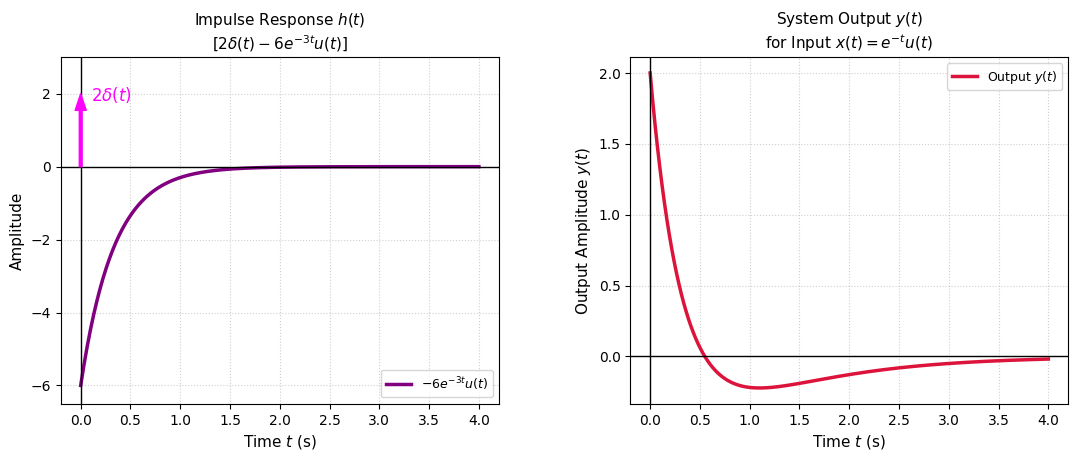

=== System Analysis & Analytical Results (Example 4) ===
• Transfer Function H(s): <TransferFunction>: sys[119]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

   2 s
  -----
  s + 3
• Pole: [-3.+0.j]
• Zero: [0.+0.j]
• BIBO Stability Status: Stable
-------------------------------------------------------
• Analytical Impulse Response h(t):
  h(t) = 2*delta(t) - 6*exp(-3t)*u(t)
• Analytical Output y(t) for x(t) = e^(-t)*u(t):
  y(t) = (-e^(-t) + 3*exp(-3t))*u(t)


In [12]:
# Notebook: Single Transfer Function Analysis with Dirac Arrow (Example 4)
import numpy as np
import matplotlib.pyplot as plt
import control as ct

# 1. Ορισμός της μίας και μοναδικής Συνάρτησης Μεταφοράς H(s) = 2s / (s + 3)
num = [2, 0]
den = [1, 3]
H = ct.tf(num, den)

def analyze_single_system_with_dirac_arrow():
    t = np.linspace(0, 4, 500)
    
    # --- Α. Υπολογισμός Κρουστικής Απόκρισης h(t) ---
    h_continuous = -6 * np.exp(-3 * t)
    
    # --- Β. Υπολογισμός Εξόδου y(t) για την είσοδο x(t) = e^{-t}u(t) ---
    x_input = np.exp(-t)
    t_y, y_resp = ct.forced_response(H, T=t, U=x_input)
    
    # Δημιουργία των δύο γραφημάτων
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
    fig.subplots_adjust(wspace=0.3)
    
    # --- Γράφημα 1: Κρουστική Απόκριση h(t) με το βελάκι της Dirac ---
    ax1.plot(t, h_continuous, color='purple', lw=2.5, label='$-6e^{-3t}u(t)$')
    
    # Σχεδίαση του βέλους για την κρούση 2δ(t) στο t=0 (με ύψος 2)
    ax1.annotate('', xy=(0, 2), xytext=(0, 0),
                 arrowprops=dict(facecolor='magenta', edgecolor='magenta', width=2, headwidth=8))
    ax1.text(0.1, 1.8, r'$2\delta(t)$', fontsize=12, color='magenta', weight='bold')
    
    # Ρύθμιση ορίων άξονα y για να φαίνεται σωστά το βελάκι πάνω και η καμπύλη κάτω
    ax1.set_ylim(-6.5, 3.0)
    ax1.axhline(0, color='black', linewidth=1)
    ax1.axvline(0, color='black', linewidth=1)
    ax1.set_xlabel('Time $t$ (s)', fontsize=11)
    ax1.set_ylabel('Amplitude', fontsize=11)
    ax1.set_title(r'Impulse Response $h(t)$' + '\n' + r'[$2\delta(t) - 6e^{-3t}u(t)$]', fontsize=11)
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend(loc='lower right', frameon=True, fontsize=9)
    
    # --- Γράφημα 2: Έξοδος y(t) για x(t) = e^{-t}u(t) ---
    ax2.plot(t_y, y_resp, color='crimson', lw=2.5, label='Output $y(t)$')
    ax2.axhline(0, color='black', linewidth=1)
    ax2.axvline(0, color='black', linewidth=1)
    ax2.set_xlabel('Time $t$ (s)', fontsize=11)
    ax2.set_ylabel('Output Amplitude $y(t)$', fontsize=11)
    ax2.set_title(r'System Output $y(t)$' + '\n' + r'for Input $x(t) = e^{-t}u(t)$', fontsize=11)
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.legend(loc='best', frameon=True, fontsize=9)
    
    plt.show()
    
    # Υπολογισμός ιδιοτήτων της συνάρτησης μεταφοράς
    p = ct.poles(H)
    z = ct.zeros(H)
    is_stable = all(np.real(p) < 0)
    
    # Εκτύπωση των στοιχείων και των αναλυτικών τύπων
    print("=== System Analysis & Analytical Results (Example 4) ===")
    print(f"• Transfer Function H(s): {H}")
    print(f"• Pole: {np.round(p, 4)}")
    print(f"• Zero: {np.round(z, 4) if len(z) > 0 else 'None'}")
    print(f"• BIBO Stability Status: {'Stable' if is_stable else 'Unstable'}")
    print("-" * 55)
    print("• Analytical Impulse Response h(t):")
    print("  h(t) = 2*delta(t) - 6*exp(-3t)*u(t)")
    print("• Analytical Output y(t) for x(t) = e^(-t)*u(t):")
    print("  y(t) = (-e^(-t) + 3*exp(-3t))*u(t)")

# Εκτέλεση
analyze_single_system_with_dirac_arrow()